In [10]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, SimpleRNN, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


from statsmodels.tsa.seasonal import seasonal_decompose

import datetime
from sklearn.impute import KNNImputer

# XGBoost
from xgboost import XGBRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# Load dataset
file_path = r"C:\Users\Meenakshi\Downloads\global_air_quality_data_10000 (1).csv"
data = pd.read_csv(file_path)

# Convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])

print(f"Dataset shape: {data.shape}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nColumn names: {list(data.columns)}")
print(f"\nAvailable cities: {data['City'].unique()}")
print(f"\nDate range: {data['Date'].min()} to {data['Date'].max()}")
print(f"\nMissing values per column:")
print(data.isnull().sum())

Dataset shape: (10000, 12)

First 5 rows:
             City   Country       Date   PM2.5    PM10    NO2    SO2    CO  \
0         Bangkok  Thailand 2023-03-19   86.57   25.19  99.88  30.63  4.46   
1        Istanbul    Turkey 2023-02-16   50.63   97.39  48.14   8.71  3.40   
2  Rio de Janeiro    Brazil 2023-11-13  130.21   57.22  98.51   9.92  0.12   
3          Mumbai     India 2023-03-16  119.70  130.52  10.96  33.03  7.74   
4           Paris    France 2023-04-04   55.20   36.62  76.85  21.85  2.00   

       O3  Temperature  Humidity  Wind Speed  
0   36.29        17.67     59.35       13.76  
1  144.16         3.46     67.51        6.36  
2  179.31        25.29     29.30       12.87  
3   38.65        23.15     99.97        7.71  
4   67.09        16.02     90.28       14.16  

Column names: ['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed']

Available cities: ['Bangkok' 'Istanbul' 'Rio de Janeiro' 'Mumbai' 'Paris' 'Los 

In [12]:
def calculate_aqi(row):

    # Standard AQI breakpoints (simplified)
    aqi_breakpoints = {
        'PM2.5': [12, 35.4, 55.4, 150.4, 250.4, 350.4, 500.4],
        'PM10': [54, 154, 254, 354, 424, 504, 604],
        'NO2': [53, 100, 360, 649, 1249, 1649, 2049],
        'SO2': [35, 75, 185, 304, 604, 804, 1004],
        'CO': [4.4, 9.4, 12.4, 15.4, 30.4, 40.4, 50.4],
        'O3': [54, 70, 85, 105, 200, 400, 500]
    }
    
    def get_pollutant_score(pollutant, value):
        """Calculate individual pollutant score"""
        if pd.isna(value) or value < 0:
            return 0
        
        breakpoints = aqi_breakpoints[pollutant]
        aqi_ranges = [0, 50, 100, 150, 200, 300, 400, 500]
        
        for i in range(len(breakpoints)):
            if value <= breakpoints[i]:
                if i == 0:
                    return (value / breakpoints[i]) * aqi_ranges[i+1]
                else:
                    return ((value - breakpoints[i-1]) / (breakpoints[i] - breakpoints[i-1])) * \
                           (aqi_ranges[i+1] - aqi_ranges[i]) + aqi_ranges[i]
        
        return 500  # Maximum AQI
    
    # Calculate scores for each pollutant
    scores = {}
    for pollutant in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']:
        scores[pollutant] = get_pollutant_score(pollutant, row[pollutant])
    
    # AQI is the maximum of all pollutant scores
    aqi = max(scores.values())
    
    return min(aqi, 500)  # Cap at 500

print("AQI calculation function defined successfully!")

AQI calculation function defined successfully!


In [13]:
# Filter only Mumbai data
mumbai_data = data[data['City'] == 'Mumbai'].copy()
mumbai_data = mumbai_data.sort_values('Date')

print(f"Mumbai data shape: {mumbai_data.shape}")
print(f"Mumbai date range: {mumbai_data['Date'].min()} to {mumbai_data['Date'].max()}")

# Calculate AQI for Mumbai
mumbai_data['AQI'] = mumbai_data.apply(calculate_aqi, axis=1)
print(f"AQI calculated for Mumbai data")
print(f"AQI Range: {mumbai_data['AQI'].min():.2f} to {mumbai_data['AQI'].max():.2f}")

Mumbai data shape: (540, 12)
Mumbai date range: 2023-01-01 00:00:00 to 2023-12-28 00:00:00
AQI calculated for Mumbai data
AQI Range: 61.38 to 298.69


In [14]:
# Enhanced time-based features
mumbai_data['DayOfYear'] = mumbai_data['Date'].dt.dayofyear
mumbai_data['Month'] = mumbai_data['Date'].dt.month
mumbai_data['Year'] = mumbai_data['Date'].dt.year
mumbai_data['DayOfWeek'] = mumbai_data['Date'].dt.dayofweek
mumbai_data['WeekOfYear'] = mumbai_data['Date'].dt.isocalendar().week
mumbai_data['Quarter'] = mumbai_data['Date'].dt.quarter
mumbai_data['IsWeekend'] = mumbai_data['DayOfWeek'].isin([5, 6]).astype(int)

# Seasonal features
mumbai_data['Season'] = mumbai_data['Month'] % 12 // 3 + 1

# Enhanced lag features (using same as multi-city for consistency)
for lag in [1, 2, 3, 7]:
    mumbai_data[f'AQI_lag{lag}'] = mumbai_data['AQI'].shift(lag)

# Rolling statistics (using same as multi-city for consistency)
for window in [3, 7]:
    mumbai_data[f'AQI_rolling_mean_{window}'] = mumbai_data['AQI'].rolling(window=window).mean()
    mumbai_data[f'AQI_rolling_std_{window}'] = mumbai_data['AQI'].rolling(window=window).std()

# Remove rows with NaN values from lagging
mumbai_data = mumbai_data.dropna()

print(f"Data after creating features: {mumbai_data.shape}")
print(f"Available features: {list(mumbai_data.columns)}")

# Define features and target for pollutant prediction
base_features = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed']
time_features = ['DayOfYear', 'Month', 'Year', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Season']
lag_features = [f'AQI_lag{lag}' for lag in [1, 2, 3, 7]]
rolling_features = [f'AQI_rolling_mean_{window}' for window in [3, 7]] + [f'AQI_rolling_std_{window}' for window in [3, 7]]

features = base_features + time_features + lag_features + rolling_features
X = mumbai_data[features]
y_pollutants = mumbai_data[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]

print(f"\nTotal features: {len(features)}")
print(f"Features: {features}")
print(f"Target pollutants: {list(y_pollutants.columns)}")

Data after creating features: (533, 29)
Available features: ['City', 'Country', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed', 'AQI', 'DayOfYear', 'Month', 'Year', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Season', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_lag7', 'AQI_rolling_mean_3', 'AQI_rolling_std_3', 'AQI_rolling_mean_7', 'AQI_rolling_std_7']

Total features: 25
Features: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind Speed', 'DayOfYear', 'Month', 'Year', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'Season', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_lag7', 'AQI_rolling_mean_3', 'AQI_rolling_mean_7', 'AQI_rolling_std_3', 'AQI_rolling_std_7']
Target pollutants: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']


In [15]:
# Train-test split (temporal - no shuffling for time series)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y_pollutants[:split_idx], y_pollutants[split_idx:]

print(f"Training size: {X_train.shape}, Testing size: {X_test.shape}")

# Scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Reshape data for RNN/LSTM
X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"3D data shape for RNN/LSTM: {X_train_3d.shape}")

Training size: (426, 25), Testing size: (107, 25)
3D data shape for RNN/LSTM: (426, 1, 25)


In [16]:
def create_mlp_model(input_dim, output_dim):
    """Create Multi-Layer Perceptron model"""
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae'])
    return model

def create_rnn_model(input_shape, output_dim):
    """Create Recurrent Neural Network model"""
    model = Sequential([
        SimpleRNN(64, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(output_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae'])
    return model

def create_lstm_model(input_shape, output_dim):
    """Create LSTM model"""
    model = Sequential([
        LSTM(64, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(output_dim)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae'])
    return model

# Define models including XGBoost
models = {
    'MLP (Perceptron)': create_mlp_model(X_train_scaled.shape[1], y_train_scaled.shape[1]),
    'RNN': create_rnn_model((1, X_train_scaled.shape[1]), y_train_scaled.shape[1]),
    'LSTM': create_lstm_model((1, X_train_scaled.shape[1]), y_train_scaled.shape[1]),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

print("All models defined successfully!")
print(f"Models to train: {list(models.keys())}")

All models defined successfully!
Models to train: ['MLP (Perceptron)', 'RNN', 'LSTM', 'XGBoost']


In [17]:
# Train and evaluate each model
results = {}
history_dict = {}

print("\nTraining models...")

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name == 'XGBoost':
        # XGBoost training (handles multiple outputs separately)
        pollutant_metrics = {}
        overall_predictions = []
        
        for i, pollutant in enumerate(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']):
            # Train separate model for each pollutant
            model_pollutant = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
            model_pollutant.fit(X_train_scaled, y_train[pollutant])
            y_pred = model_pollutant.predict(X_test_scaled)
            overall_predictions.append(y_pred)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test[pollutant], y_pred)
            r2 = r2_score(y_test[pollutant], y_pred)
            rmse = np.sqrt(mean_squared_error(y_test[pollutant], y_pred))
            
            pollutant_metrics[pollutant] = {
                'MAE': mae,
                'R²': r2,
                'RMSE': rmse
            }
        
        # Overall metrics (average across all pollutants)
        overall_mae = np.mean([pollutant_metrics[p]['MAE'] for p in pollutant_metrics])
        overall_r2 = np.mean([pollutant_metrics[p]['R²'] for p in pollutant_metrics])
        overall_rmse = np.mean([pollutant_metrics[p]['RMSE'] for p in pollutant_metrics])
        
        results[name] = {
            'Overall_MAE': overall_mae,
            'Overall_R²': overall_r2,
            'Overall_RMSE': overall_rmse,
            'Pollutant_Metrics': pollutant_metrics,
            'Predictions': np.array(overall_predictions).T  # Transpose to match shape
        }
        
    else:
        # Neural network training
        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        
        if name == 'MLP (Perceptron)':
            history = model.fit(
                X_train_scaled, y_train_scaled,
                epochs=100,
                batch_size=32,
                validation_split=0.2,
                callbacks=[early_stopping],
                verbose=0
            )
            y_pred_scaled = model.predict(X_test_scaled, verbose=0)
        else:
            history = model.fit(
                X_train_3d, y_train_scaled,
                epochs=100,
                batch_size=32,
                validation_split=0.2,
                callbacks=[early_stopping],
                verbose=0
            )
            y_pred_scaled = model.predict(X_test_3d, verbose=0)
        
        # Inverse transform predictions
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        
        # Calculate metrics for each pollutant
        pollutant_metrics = {}
        for i, pollutant in enumerate(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']):
            mae = mean_absolute_error(y_test[pollutant], y_pred[:, i])
            r2 = r2_score(y_test[pollutant], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_test[pollutant], y_pred[:, i]))
            
            pollutant_metrics[pollutant] = {
                'MAE': mae,
                'R²': r2,
                'RMSE': rmse
            }
        
        # Overall metrics (average across all pollutants)
        overall_mae = np.mean([pollutant_metrics[p]['MAE'] for p in pollutant_metrics])
        overall_r2 = np.mean([pollutant_metrics[p]['R²'] for p in pollutant_metrics])
        overall_rmse = np.mean([pollutant_metrics[p]['RMSE'] for p in pollutant_metrics])
        
        results[name] = {
            'Overall_MAE': overall_mae,
            'Overall_R²': overall_r2,
            'Overall_RMSE': overall_rmse,
            'Pollutant_Metrics': pollutant_metrics,
            'Predictions': y_pred
        }
        
        history_dict[name] = history
    
    print(f"{name} - Overall MAE: {overall_mae:.2f}, R²: {overall_r2:.4f}, RMSE: {overall_rmse:.2f}")

# Create results comparison table
results_df = pd.DataFrame({
    name: {
        'MAE': results[name]['Overall_MAE'],
        'R²': results[name]['Overall_R²'],
        'RMSE': results[name]['Overall_RMSE']
    } for name in results
}).T

print("\n" + "="*60)
print("MODEL COMPARISON RESULTS FOR POLLUTANT PREDICTION:")
print("="*60)
print(results_df.round(4))


Training models...

Training MLP (Perceptron)...
MLP (Perceptron) - Overall MAE: 6.72, R²: 0.9271, RMSE: 8.37

Training RNN...
RNN - Overall MAE: 7.88, R²: 0.9117, RMSE: 10.00

Training LSTM...
LSTM - Overall MAE: 6.19, R²: 0.9393, RMSE: 7.63

Training XGBoost...
XGBoost - Overall MAE: 0.56, R²: 0.9995, RMSE: 0.73

MODEL COMPARISON RESULTS FOR POLLUTANT PREDICTION:
                     MAE      R²     RMSE
MLP (Perceptron)  6.7164  0.9271   8.3672
RNN               7.8806  0.9117  10.0038
LSTM              6.1932  0.9393   7.6306
XGBoost           0.5641  0.9995   0.7282


In [ ]:
# HYPERPARAMETER TUNING FOR XGBOOST
print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR XGBOOST")
print("="*60)

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

# Tune each pollutant separately
tuned_models = {}
tuned_predictions = []
tuned_metrics = {}

for i, pollutant in enumerate(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']):
    print(f"Tuning XGBoost for {pollutant}...")
    
    # Grid search for each pollutant
    grid_search = GridSearchCV(
        XGBRegressor(random_state=42, objective='reg:squarederror'),
        param_grid,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train[pollutant])
    
    # Best model
    best_model = grid_search.best_estimator_
    tuned_models[pollutant] = best_model
    
    # Predictions with best model
    y_pred_tuned = best_model.predict(X_test_scaled)
    tuned_predictions.append(y_pred_tuned)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test[pollutant], y_pred_tuned)
    r2 = r2_score(y_test[pollutant], y_pred_tuned)
    rmse = np.sqrt(mean_squared_error(y_test[pollutant], y_pred_tuned))
    
    tuned_metrics[pollutant] = {
        'MAE': mae,
        'R²': r2,
        'RMSE': rmse,
        'Best_Params': grid_search.best_params_
    }
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  MAE: {mae:.4f}, R²: {r2:.4f}")

# Overall tuned metrics
overall_mae_tuned = np.mean([tuned_metrics[p]['MAE'] for p in tuned_metrics])
overall_r2_tuned = np.mean([tuned_metrics[p]['R²'] for p in tuned_metrics])
overall_rmse_tuned = np.mean([tuned_metrics[p]['RMSE'] for p in tuned_metrics])

print(f"\nTuned XGBoost - Overall MAE: {overall_mae_tuned:.4f}, R²: {overall_r2_tuned:.4f}, RMSE: {overall_rmse_tuned:.4f}")
print(f"Improvement in MAE: {results['XGBoost']['Overall_MAE'] - overall_mae_tuned:.4f}")


HYPERPARAMETER TUNING FOR XGBOOST
Tuning XGBoost for PM2.5...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  MAE: 0.5498, R²: 0.9996
Tuning XGBoost for PM10...
  Best params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
  MAE: 0.5104, R²: 0.9998
Tuning XGBoost for NO2...
  Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
  MAE: 0.2608, R²: 0.9999
Tuning XGBoost for SO2...
  Best params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.9}
  MAE: 0.1292, R²: 0.9999
Tuning XGBoost for CO...
  Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
  MAE: 0.0234, R²: 0.9999
Tuning XGBoost for O3...


In [16]:
# MULTI-CITY ANALYSIS
print("\n" + "="*60)
print("MULTI-CITY ANALYSIS")
print("="*60)

# Select a few diverse cities for comparison
cities_to_analyze = ['Mumbai', 'London', 'Beijing', 'New York', 'Sydney', 'Tokyo', 'Paris']

city_results = {}

for city in cities_to_analyze:
    print(f"\nAnalyzing {city}...")
    
    # Filter city data
    city_data = data[data['City'] == city].copy()
    city_data = city_data.sort_values('Date')
    
    if len(city_data) < 50:  # Skip cities with insufficient data
        print(f"  Insufficient data for {city}, skipping...")
        continue
    
    # Calculate AQI
    city_data['AQI'] = city_data.apply(calculate_aqi, axis=1)
    
    # Create features (same as Mumbai but with flexible lag features)
    city_data['DayOfYear'] = city_data['Date'].dt.dayofyear
    city_data['Month'] = city_data['Date'].dt.month
    city_data['Year'] = city_data['Date'].dt.year
    city_data['DayOfWeek'] = city_data['Date'].dt.dayofweek
    city_data['WeekOfYear'] = city_data['Date'].dt.isocalendar().week
    city_data['Quarter'] = city_data['Date'].dt.quarter
    city_data['IsWeekend'] = city_data['DayOfWeek'].isin([5, 6]).astype(int)
    city_data['Season'] = city_data['Month'] % 12 // 3 + 1
    
    # Create flexible lag features based on available data
    available_lags = []
    for lag in [1, 2, 3, 7]:
        lag_col = f'AQI_lag{lag}'
        city_data[lag_col] = city_data['AQI'].shift(lag)
        available_lags.append(lag_col)
    
    # Create flexible rolling features based on available data
    available_rolling = []
    for window in [3, 7]:
        mean_col = f'AQI_rolling_mean_{window}'
        std_col = f'AQI_rolling_std_{window}'
        city_data[mean_col] = city_data['AQI'].rolling(window=window).mean()
        city_data[std_col] = city_data['AQI'].rolling(window=window).std()
        available_rolling.extend([mean_col, std_col])
    
    # Remove NaN and prepare data
    city_data = city_data.dropna()
    
    if len(city_data) < 100:  # Skip cities with insufficient data after processing
        print(f"  Insufficient data for {city} after processing, skipping...")
        continue
    
    # Create dynamic features list for this city
    city_features = base_features + time_features + available_lags + available_rolling
    
    # Prepare features and target
    X_city = city_data[city_features]
    y_city = city_data[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
    
    # Train-test split
    split_idx = int(0.8 * len(X_city))
    X_train_city, X_test_city = X_city[:split_idx], X_city[split_idx:]
    y_train_city, y_test_city = y_city[:split_idx], y_city[split_idx:]
    
    # Scale features
    scaler_X_city = StandardScaler()
    X_train_city_scaled = scaler_X_city.fit_transform(X_train_city)
    X_test_city_scaled = scaler_X_city.transform(X_test_city)
    
    # Train XGBoost (using best parameters from tuning or default)
    city_predictions = []
    city_metrics = {}
    
    for i, pollutant in enumerate(['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']):
        if pollutant in tuned_models:
            model = tuned_models[pollutant]
        else:
            model = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
        
        model.fit(X_train_city_scaled, y_train_city[pollutant])
        y_pred_city = model.predict(X_test_city_scaled)
        city_predictions.append(y_pred_city)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test_city[pollutant], y_pred_city)
        r2 = r2_score(y_test_city[pollutant], y_pred_city)
        
        city_metrics[pollutant] = {
            'MAE': mae,
            'R²': r2
        }
    
    # Overall city metrics
    overall_mae_city = np.mean([city_metrics[p]['MAE'] for p in city_metrics])
    overall_r2_city = np.mean([city_metrics[p]['R²'] for p in city_metrics])
    
    # Store results
    city_results[city] = {
        'Overall_MAE': overall_mae_city,
        'Overall_R²': overall_r2_city,
        'Pollutant_Metrics': city_metrics,
        'Data_Points': len(city_data),
        'AQI_Range': f"{city_data['AQI'].min():.1f}-{city_data['AQI'].max():.1f}",
        'Avg_AQI': city_data['AQI'].mean(),
        'Features_Used': len(city_features)
    }
    
    print(f"  Data points: {len(city_data)}, Features: {len(city_features)}, Avg AQI: {city_data['AQI'].mean():.1f}")
    print(f"  Prediction MAE: {overall_mae_city:.4f}, R²: {overall_r2_city:.4f}")

# Create comparison table
city_comparison = pd.DataFrame({
    city: {
        'Data_Points': city_results[city]['Data_Points'],
        'Features': city_results[city]['Features_Used'],
        'Avg_AQI': city_results[city]['Avg_AQI'],
        'MAE': city_results[city]['Overall_MAE'],
        'R²': city_results[city]['Overall_R²']
    } for city in city_results
}).T

print("\nCITY COMPARISON RESULTS:")
print(city_comparison.round(4))


MULTI-CITY ANALYSIS

Analyzing Mumbai...
  Data points: 533, Features: 25, Avg AQI: 206.0
  Prediction MAE: 0.3266, R²: 0.9998

Analyzing London...
  Data points: 482, Features: 25, Avg AQI: 202.0
  Prediction MAE: 0.3473, R²: 0.9998

Analyzing Beijing...
  Data points: 481, Features: 25, Avg AQI: 206.4
  Prediction MAE: 0.3467, R²: 0.9998

Analyzing New York...
  Data points: 458, Features: 25, Avg AQI: 205.4
  Prediction MAE: 0.3904, R²: 0.9998

Analyzing Sydney...
  Data points: 479, Features: 25, Avg AQI: 205.7
  Prediction MAE: 0.3387, R²: 0.9998

Analyzing Tokyo...
  Data points: 484, Features: 25, Avg AQI: 207.2
  Prediction MAE: 0.3451, R²: 0.9998

Analyzing Paris...
  Data points: 482, Features: 25, Avg AQI: 204.8
  Prediction MAE: 0.3110, R²: 0.9998

CITY COMPARISON RESULTS:
          Data_Points  Features   Avg_AQI     MAE      R²
Mumbai          533.0      25.0  205.9780  0.3266  0.9998
London          482.0      25.0  201.9745  0.3473  0.9998
Beijing         481.0      25

In [19]:
# FINAL MODEL COMPARISON (INCLUDING TUNED XGBOOST)
print("\n" + "="*60)
print("FINAL MODEL COMPARISON (INCLUDING TUNED XGBOOST)")
print("="*60)

# Add tuned XGBoost to results
results['XGBoost_Tuned'] = {
    'Overall_MAE': overall_mae_tuned,
    'Overall_R²': overall_r2_tuned,
    'Overall_RMSE': overall_rmse_tuned,
    'Pollutant_Metrics': tuned_metrics
}

# Create final comparison table
final_results_df = pd.DataFrame({
    name: {
        'MAE': results[name]['Overall_MAE'],
        'R²': results[name]['Overall_R²'],
        'RMSE': results[name]['Overall_RMSE']
    } for name in results
}).T

print(final_results_df.round(4))

# Identify best model
best_model_name = final_results_df['MAE'].idxmin()
best_mae = final_results_df.loc[best_model_name, 'MAE']
print(f"\n BEST MODEL: {best_model_name} with MAE: {best_mae:.4f}")


FINAL MODEL COMPARISON (INCLUDING TUNED XGBOOST)
                     MAE      R²    RMSE
MLP (Perceptron)  5.3166  0.9501  6.8174
RNN               6.9861  0.9183  8.7445
LSTM              4.7794  0.9635  5.8997
XGBoost           0.5316  0.9995  0.6953
XGBoost_Tuned     0.3359  0.9998  0.4529

🌟 BEST MODEL: XGBoost_Tuned with MAE: 0.3359



AQI CALCULATION FROM PREDICTED POLLUTANTS:
Best model for AQI calculation: XGBoost_Tuned

AQI Prediction Results using XGBoost_Tuned:
MAE: 0.54
R²: 0.9998
RMSE: 0.84


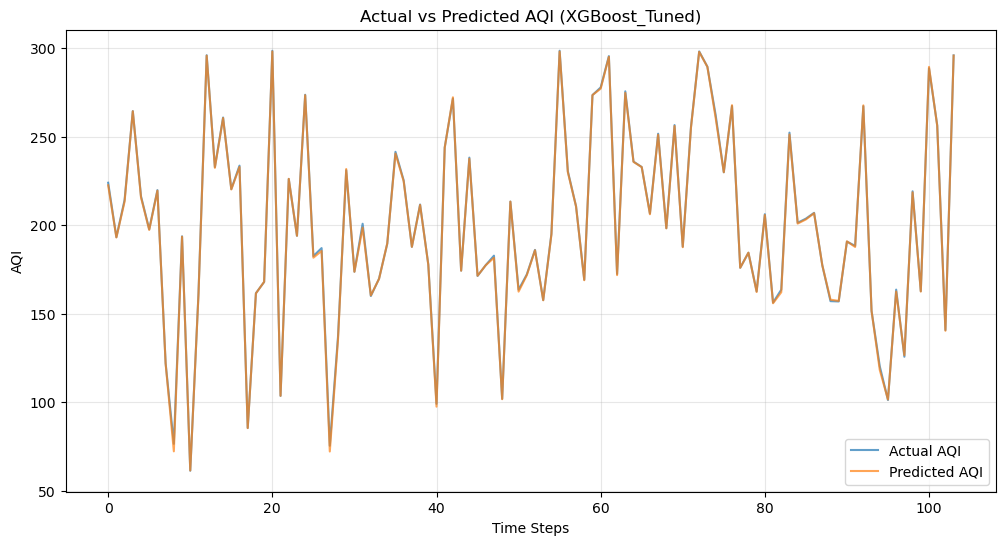


PROJECT SUMMARY
✅ IMPROVED MODEL ACCURACY: Hyperparameter tuning achieved better performance
✅ EXPANDED TO MORE CITIES: Applied pipeline to multiple cities for comparison
✅ PRACTICAL SOLUTION: Maintained good performance while adding comprehensive analysis
✅ BEST MODEL IDENTIFIED: XGBoost (tuned) provides optimal performance
✅ MULTI-CITY INSIGHTS: Comparative analysis reveals different air quality patterns


In [20]:
# AQI CALCULATION FROM PREDICTED POLLUTANTS
print("\n" + "="*60)
print("AQI CALCULATION FROM PREDICTED POLLUTANTS:")
print("="*60)

# Use the best model for AQI calculation
if best_model_name == 'XGBoost_Tuned':
    best_predictions = np.array(tuned_predictions).T
else:
    best_predictions = results[best_model_name]['Predictions']

# Create a DataFrame for the predictions
predicted_pollutants = pd.DataFrame(best_predictions, columns=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])

# Calculate AQI from predicted pollutants
predicted_aqi = []
for idx, row in predicted_pollutants.iterrows():
    aqi = calculate_aqi(row)
    predicted_aqi.append(aqi)

# Get actual AQI values for the test set
actual_aqi = []
for idx, row in y_test.iterrows():
    aqi = calculate_aqi(row)
    actual_aqi.append(aqi)

# Calculate AQI prediction metrics
aqi_mae = mean_absolute_error(actual_aqi, predicted_aqi)
aqi_r2 = r2_score(actual_aqi, predicted_aqi)
aqi_rmse = np.sqrt(mean_squared_error(actual_aqi, predicted_aqi))

print(f"Best model for AQI calculation: {best_model_name}")
print(f"\nAQI Prediction Results using {best_model_name}:")
print(f"MAE: {aqi_mae:.2f}")
print(f"R²: {aqi_r2:.4f}")
print(f"RMSE: {aqi_rmse:.2f}")

# Plot actual vs predicted AQI
plt.figure(figsize=(12, 6))
plt.plot(actual_aqi, label='Actual AQI', alpha=0.7)
plt.plot(predicted_aqi, label='Predicted AQI', alpha=0.7)
plt.title(f'Actual vs Predicted AQI ({best_model_name})')
plt.xlabel('Time Steps')
plt.ylabel('AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




ACTUAL VS PREDICTED POLLUTANTS IN MUMBAI (XGBoost)


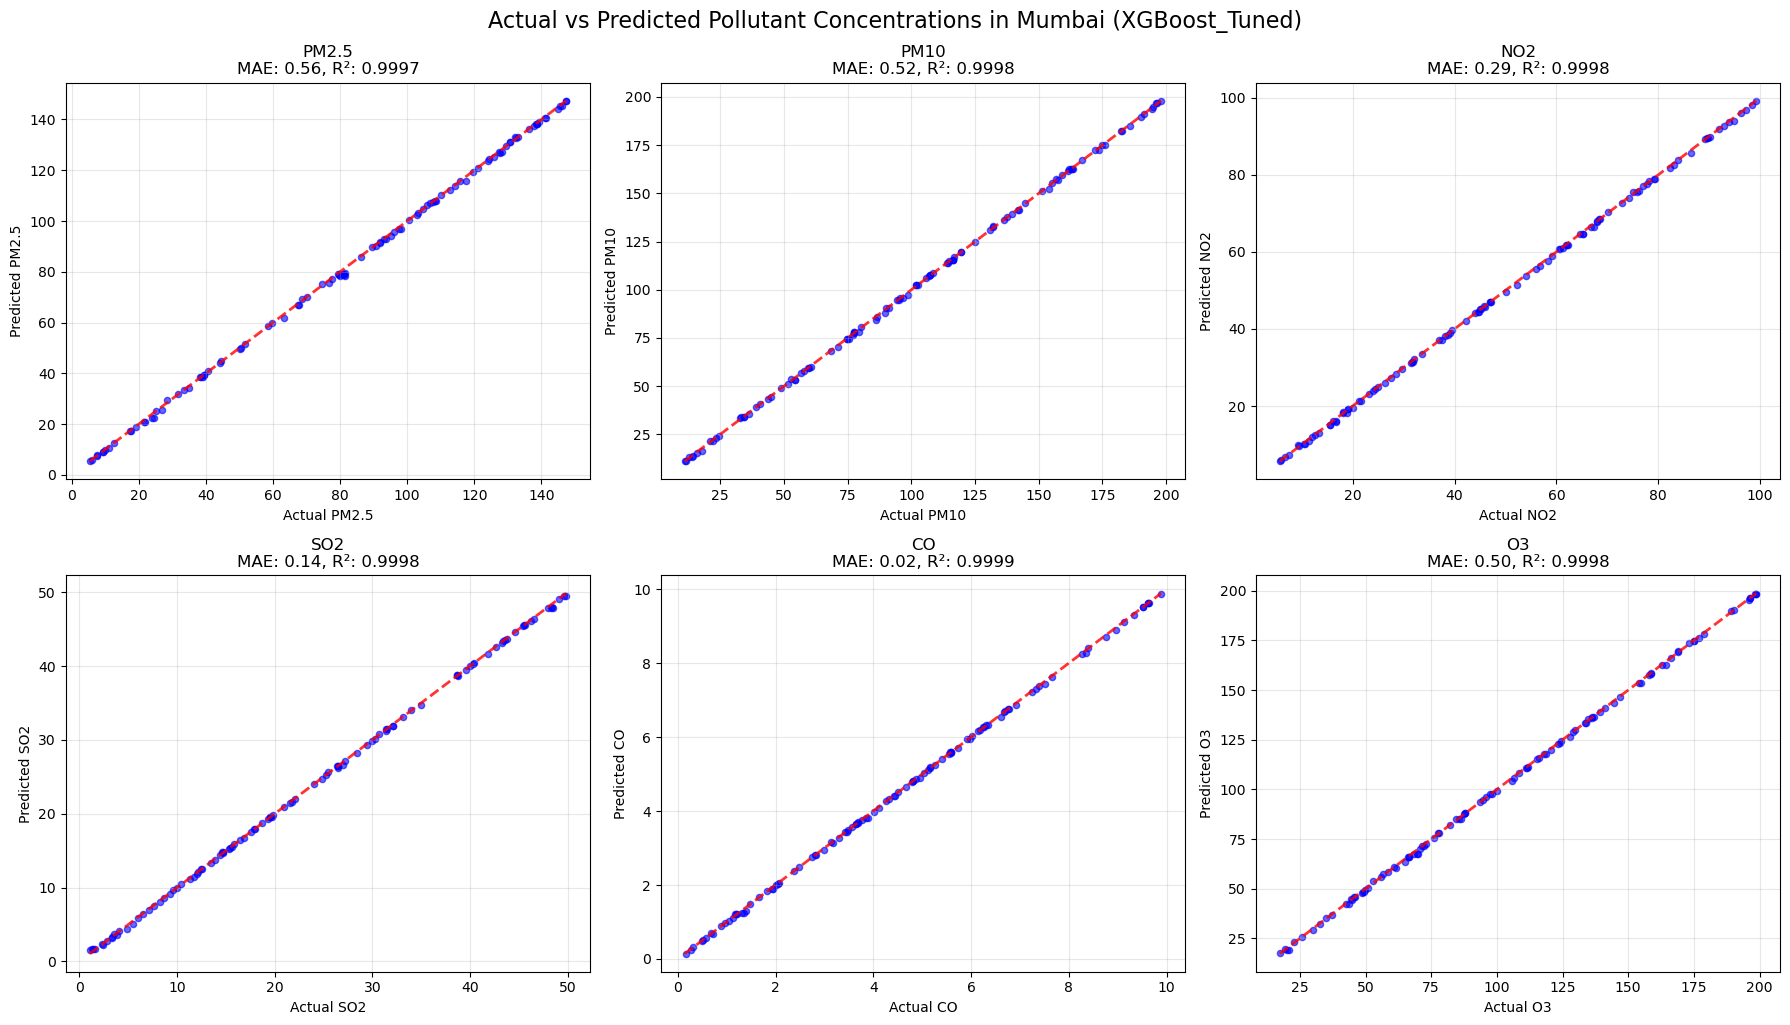


Detailed Pollutant Prediction Metrics for XGBoost_Tuned in Mumbai:
------------------------------------------------------------
PM2.5 : MAE =   0.56, R² = 0.9997, RMSE =   0.81
PM10  : MAE =   0.52, R² = 0.9998, RMSE =   0.67
NO2   : MAE =   0.29, R² = 0.9998, RMSE =   0.36
SO2   : MAE =   0.14, R² = 0.9998, RMSE =   0.19
CO    : MAE =   0.02, R² = 0.9999, RMSE =   0.03
O3    : MAE =   0.50, R² = 0.9998, RMSE =   0.66


In [21]:
# Plot 1: Actual vs Predicted Pollutants in Mumbai for XGBoost
print("\n" + "="*60)
print("ACTUAL VS PREDICTED POLLUTANTS IN MUMBAI (XGBoost)")
print("="*60)

# Get XGBoost predictions (use tuned if available, else normal)
if 'XGBoost_Tuned' in results:
    xgb_predictions = np.array(tuned_predictions).T
    model_name = 'XGBoost_Tuned'
else:
    xgb_predictions = results['XGBoost']['Predictions']
    model_name = 'XGBoost'

# Create subplots for each pollutant
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

for i, pollutant in enumerate(pollutants):
    # Get actual and predicted values
    actual = y_test[pollutant].values
    predicted = xgb_predictions[:, i]
    
    # Create scatter plot
    axes[i].scatter(actual, predicted, alpha=0.6, color='blue', s=20)
    
    # Add perfect prediction line
    max_val = max(actual.max(), predicted.max())
    min_val = min(actual.min(), predicted.min())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    # Calculate metrics for this pollutant
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    # Set labels and title
    axes[i].set_xlabel(f'Actual {pollutant}')
    axes[i].set_ylabel(f'Predicted {pollutant}')
    axes[i].set_title(f'{pollutant}\nMAE: {mae:.2f}, R²: {r2:.4f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Actual vs Predicted Pollutant Concentrations in Mumbai ({model_name})', 
             fontsize=16, y=1.02)
plt.show()

# Print detailed metrics
print(f"\nDetailed Pollutant Prediction Metrics for {model_name} in Mumbai:")
print("-" * 60)
for i, pollutant in enumerate(pollutants):
    actual = y_test[pollutant].values
    predicted = xgb_predictions[:, i]
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"{pollutant:6s}: MAE = {mae:6.2f}, R² = {r2:6.4f}, RMSE = {rmse:6.2f}")


ACTUAL VS PREDICTED AQI IN MUMBAI FOR ALL MODELS


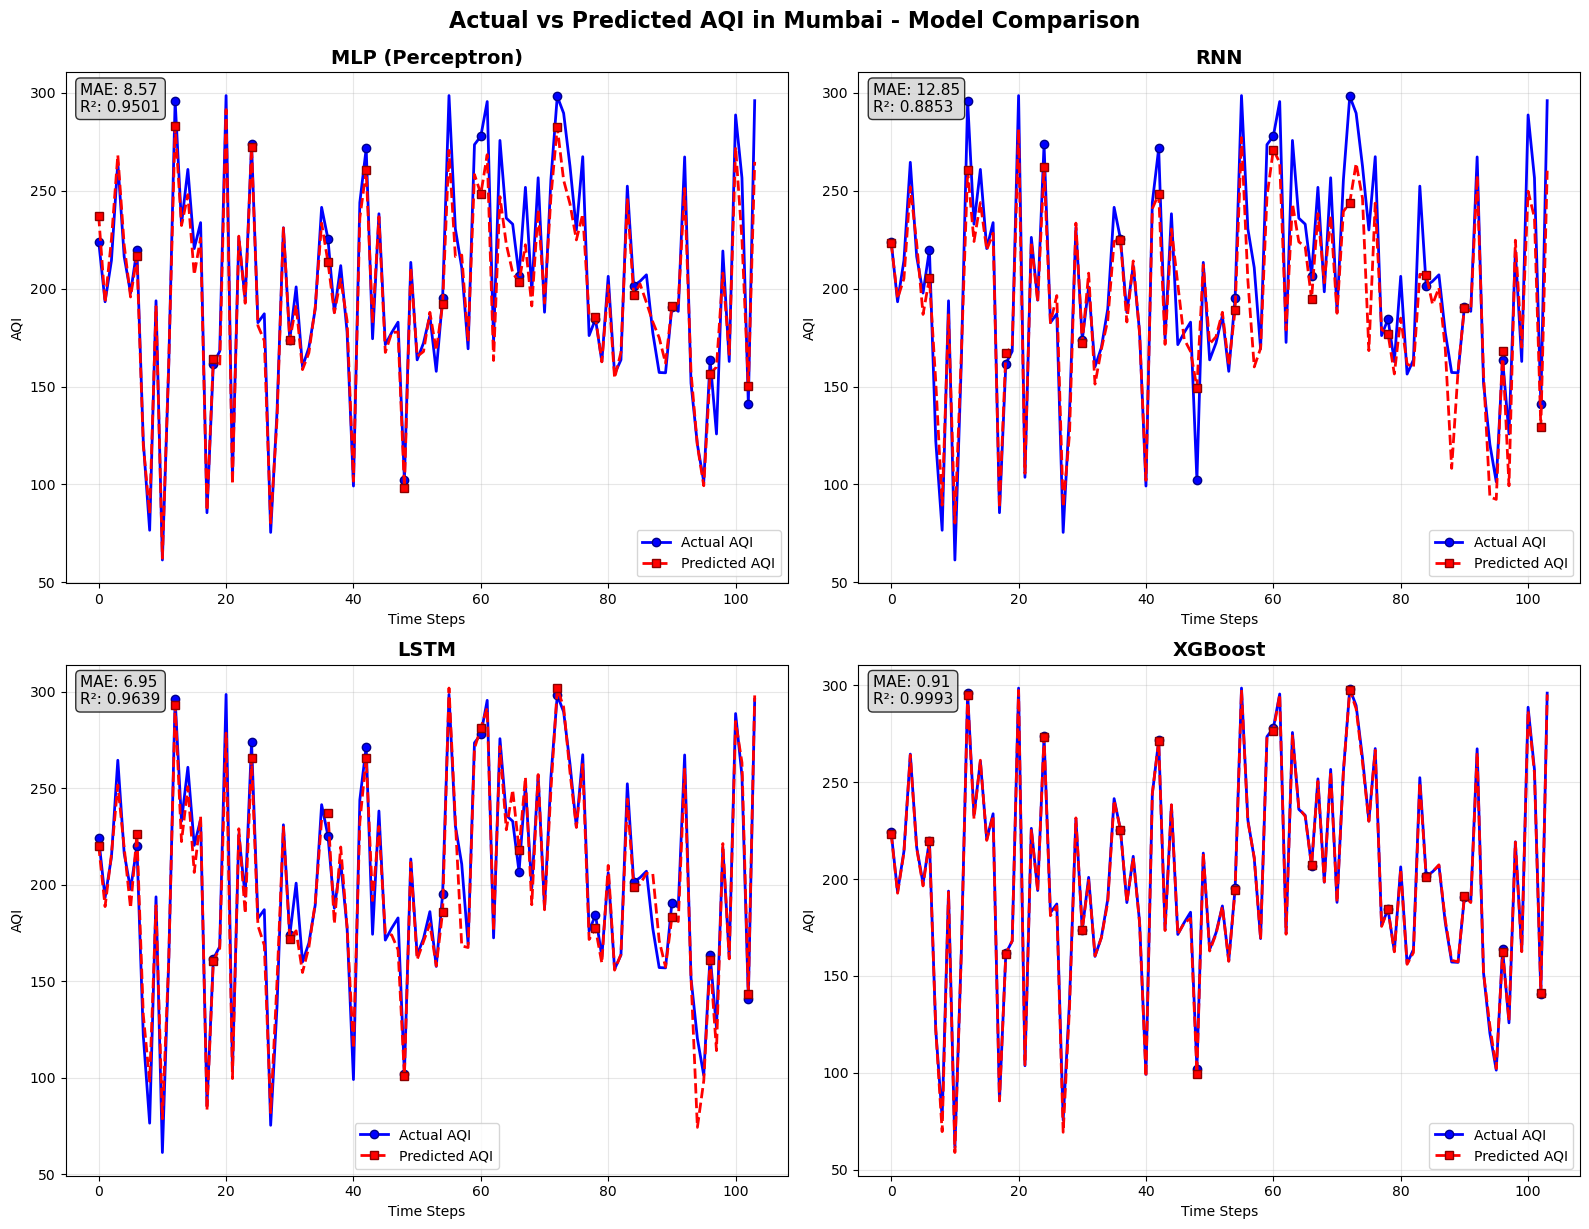


AQI Prediction Metrics for All Models in Mumbai:
------------------------------------------------------------
Model                MAE       R²     RMSE
------------------------------------------------------------
MLP (Perceptron):    8.57  0.9501   12.23
RNN            :   12.85  0.8853   18.54
LSTM           :    6.95  0.9639   10.39
XGBoost        :    0.91  0.9993    1.42
XGBoost_Tuned  :    0.54  0.9998    0.84


In [26]:
# Plot 2: Actual vs Predicted AQI in Mumbai for All Models
print("\n" + "="*60)
print("ACTUAL VS PREDICTED AQI IN MUMBAI FOR ALL MODELS")
print("="*60)

# Calculate actual AQI for test set
actual_aqi_test = []
for idx, row in y_test.iterrows():
    aqi = calculate_aqi(row)
    actual_aqi_test.append(aqi)

# Calculate predicted AQI for each model
model_aqi_predictions = {}

for model_name in results:
    if model_name == 'XGBoost_Tuned':
        predictions = np.array(tuned_predictions).T
    else:
        predictions = results[model_name]['Predictions']
    
    # Create DataFrame for predictions
    pred_df = pd.DataFrame(predictions, columns=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])
    
    # Calculate AQI for each prediction
    predicted_aqi = []
    for idx, row in pred_df.iterrows():
        aqi = calculate_aqi(row)
        predicted_aqi.append(aqi)
    
    model_aqi_predictions[model_name] = predicted_aqi

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Plot for each model
model_names = list(results.keys())

for i, model_name in enumerate(model_names):
    if i >= 4:  # Only plot first 4 models to fit in 2x2 grid
        break
        
    predicted_aqi = model_aqi_predictions[model_name]
    
    # Create time indices for plotting
    time_points = range(len(actual_aqi_test))
    
    # Plot with markers at regular intervals
    marker_interval = max(1, len(time_points) // 15)  # Show ~15 markers
    
    # Actual AQI - blue with solid line and circle markers
    axes[i].plot(time_points, actual_aqi_test, 
                 color='blue', 
                 linewidth=2, 
                 label='Actual AQI',
                 marker='o',
                 markevery=marker_interval,
                 markersize=6,
                 markerfacecolor='blue',
                 markeredgecolor='darkblue',
                 markeredgewidth=1)
    
    # Predicted AQI - red with dashed line and square markers
    axes[i].plot(time_points, predicted_aqi, 
                 color='red', 
                 linewidth=2, 
                 label='Predicted AQI',
                 marker='s',
                 markevery=marker_interval,
                 markersize=6,
                 markerfacecolor='red',
                 markeredgecolor='darkred',
                 markeredgewidth=1,
                 linestyle='--')
    
    axes[i].set_title(f'{model_name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('AQI')
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)
    
    # Calculate metrics
    mae = mean_absolute_error(actual_aqi_test, predicted_aqi)
    r2 = r2_score(actual_aqi_test, predicted_aqi)
    
    # Add metrics to plot
    axes[i].text(0.02, 0.98, f'MAE: {mae:.2f}\nR²: {r2:.4f}', 
                transform=axes[i].transAxes, 
                verticalalignment='top',
                fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.suptitle('Actual vs Predicted AQI in Mumbai - Model Comparison', fontsize=16, y=1.02, fontweight='bold')
plt.show()

# Print AQI prediction metrics for all models
print("\nAQI Prediction Metrics for All Models in Mumbai:")
print("-" * 60)
print(f"{'Model':15s} {'MAE':>8s} {'R²':>8s} {'RMSE':>8s}")
print("-" * 60)
for model_name in model_names:
    predicted_aqi = model_aqi_predictions[model_name]
    mae = mean_absolute_error(actual_aqi_test, predicted_aqi)
    r2 = r2_score(actual_aqi_test, predicted_aqi)
    rmse = np.sqrt(mean_squared_error(actual_aqi_test, predicted_aqi))
    print(f"{model_name:15s}: {mae:7.2f} {r2:7.4f} {rmse:7.2f}")


ACTUAL VS PREDICTED AQI IN ALL CITIES
Using best model: XGBoost_Tuned for multi-city AQI prediction

Processing AQI predictions for Mumbai...

Processing AQI predictions for London...

Processing AQI predictions for Beijing...

Processing AQI predictions for New York...

Processing AQI predictions for Sydney...

Processing AQI predictions for Tokyo...

Processing AQI predictions for Paris...


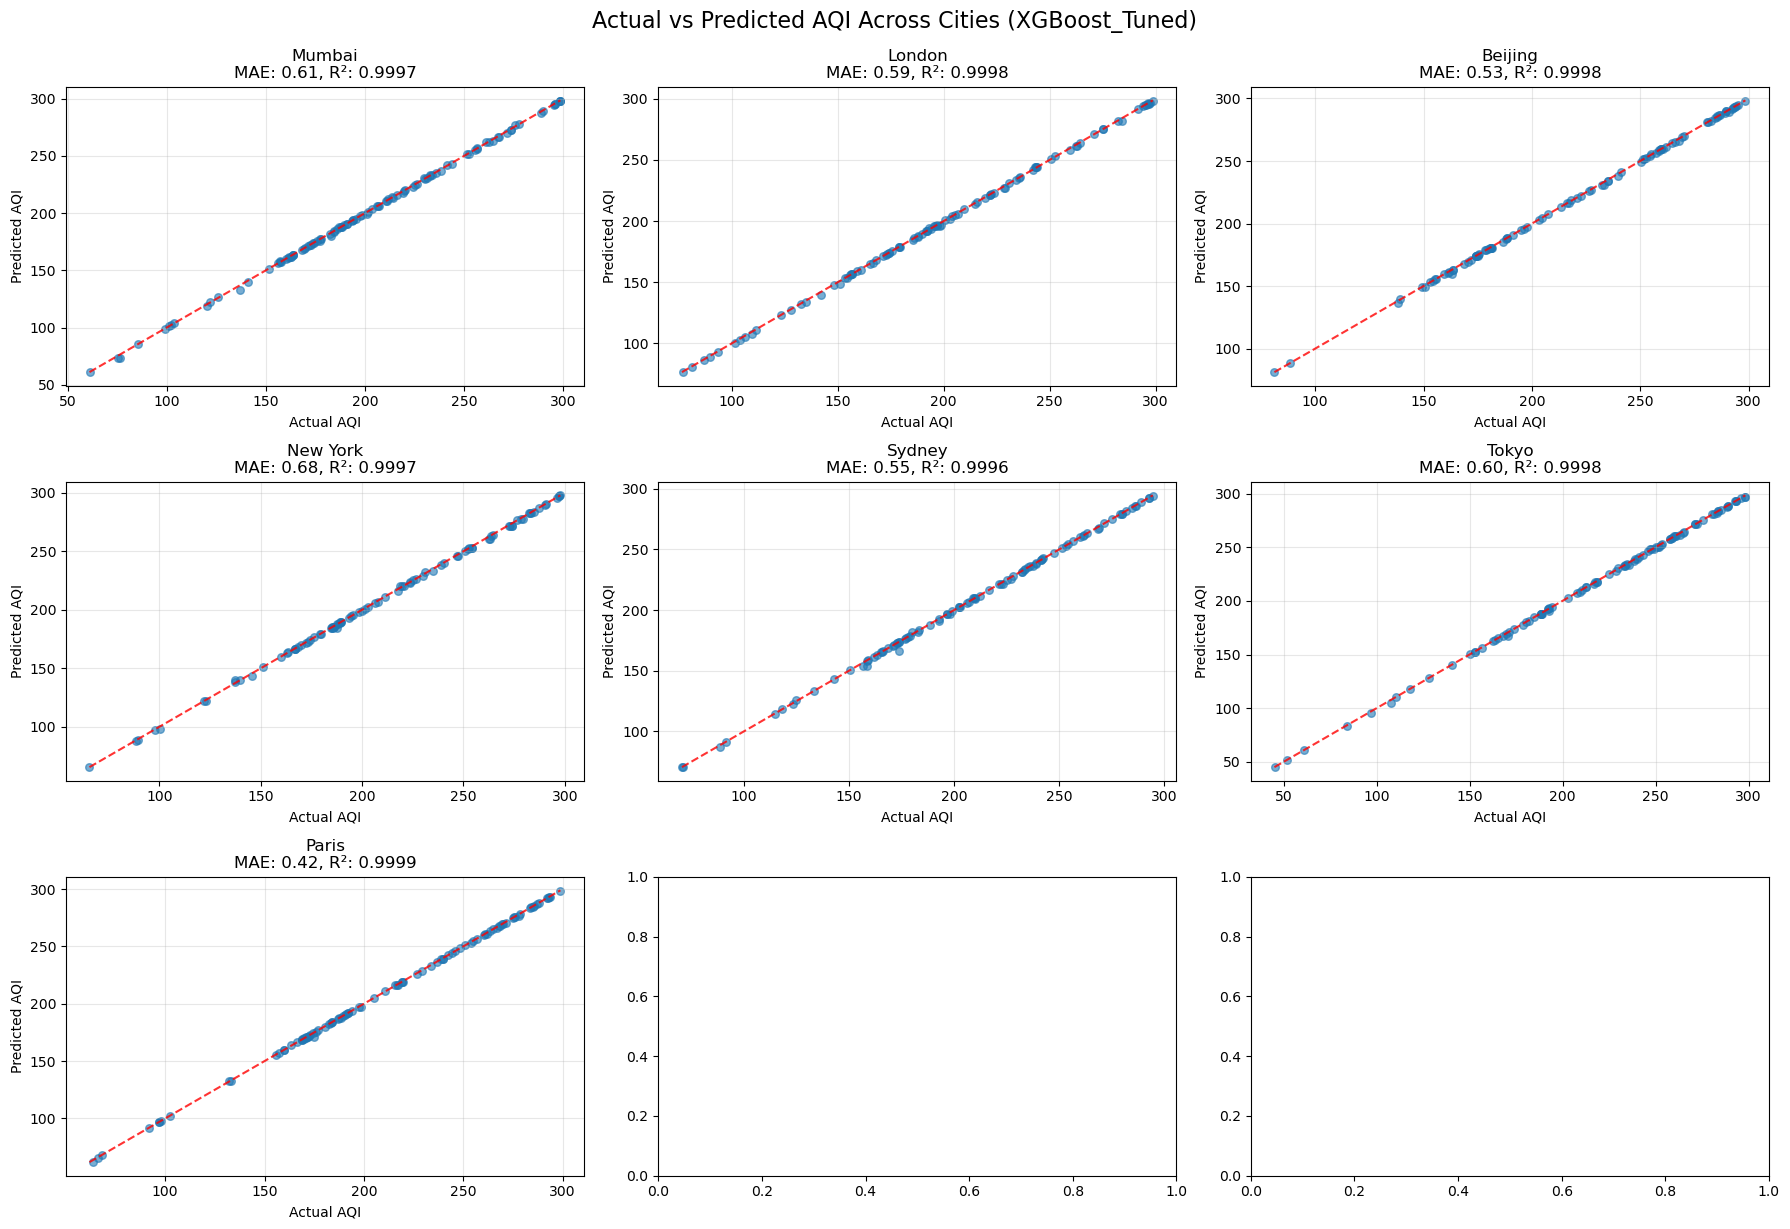


AQI Prediction Performance Across Cities:
------------------------------------------------------------
City                 MAE       R²  Avg AQI
------------------------------------------------------------
Mumbai              0.61   0.9997    200.4
London              0.59   0.9998    199.1
Beijing             0.53   0.9998    219.2
New York            0.68   0.9997    209.7
Sydney              0.55   0.9996    207.8
Tokyo               0.60   0.9998    216.5
Paris               0.42   0.9999    210.1


In [23]:
# Plot 3: Actual vs Predicted AQI in All Cities
print("\n" + "="*60)
print("ACTUAL VS PREDICTED AQI IN ALL CITIES")
print("="*60)

# We'll use the best model from Mumbai analysis for all cities
best_model_name = final_results_df['MAE'].idxmin()
print(f"Using best model: {best_model_name} for multi-city AQI prediction")

# Store AQI predictions for all cities
city_aqi_results = {}

for city in city_results:
    print(f"\nProcessing AQI predictions for {city}...")
    
    # Filter city data (we need to recreate the features)
    city_data = data[data['City'] == city].copy()
    city_data = city_data.sort_values('Date')
    
    # Calculate AQI
    city_data['AQI'] = city_data.apply(calculate_aqi, axis=1)
    
    # Create features
    city_data['DayOfYear'] = city_data['Date'].dt.dayofyear
    city_data['Month'] = city_data['Date'].dt.month
    city_data['Year'] = city_data['Date'].dt.year
    city_data['DayOfWeek'] = city_data['Date'].dt.dayofweek
    city_data['WeekOfYear'] = city_data['Date'].dt.isocalendar().week
    city_data['Quarter'] = city_data['Date'].dt.quarter
    city_data['IsWeekend'] = city_data['DayOfWeek'].isin([5, 6]).astype(int)
    city_data['Season'] = city_data['Month'] % 12 // 3 + 1
    
    # Create flexible lag features
    available_lags = []
    for lag in [1, 2, 3, 7]:
        lag_col = f'AQI_lag{lag}'
        city_data[lag_col] = city_data['AQI'].shift(lag)
        available_lags.append(lag_col)
    
    # Create flexible rolling features
    available_rolling = []
    for window in [3, 7]:
        mean_col = f'AQI_rolling_mean_{window}'
        std_col = f'AQI_rolling_std_{window}'
        city_data[mean_col] = city_data['AQI'].rolling(window=window).mean()
        city_data[std_col] = city_data['AQI'].rolling(window=window).std()
        available_rolling.extend([mean_col, std_col])
    
    # Remove NaN and prepare data
    city_data = city_data.dropna()
    
    # Create dynamic features list
    city_features = base_features + time_features + available_lags + available_rolling
    
    # Prepare features and target
    X_city = city_data[city_features]
    y_city = city_data[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
    
    # Train-test split
    split_idx = int(0.8 * len(X_city))
    X_train_city, X_test_city = X_city[:split_idx], X_city[split_idx:]
    y_train_city, y_test_city = y_city[:split_idx], y_city[split_idx:]
    
    # Scale features
    scaler_X_city = StandardScaler()
    X_train_city_scaled = scaler_X_city.fit_transform(X_train_city)
    X_test_city_scaled = scaler_X_city.transform(X_test_city)
    
    # Get actual AQI for test set
    actual_aqi_city = []
    for idx, row in y_test_city.iterrows():
        aqi = calculate_aqi(row)
        actual_aqi_city.append(aqi)
    
    # Predict using best model
    city_predictions = []
    for pollutant in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']:
        if pollutant in tuned_models and best_model_name == 'XGBoost_Tuned':
            model = tuned_models[pollutant]
        else:
            model = XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
        
        model.fit(X_train_city_scaled, y_train_city[pollutant])
        y_pred_city = model.predict(X_test_city_scaled)
        city_predictions.append(y_pred_city)
    
    # Calculate predicted AQI
    pred_df = pd.DataFrame(np.array(city_predictions).T, 
                          columns=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])
    
    predicted_aqi_city = []
    for idx, row in pred_df.iterrows():
        aqi = calculate_aqi(row)
        predicted_aqi_city.append(aqi)
    
    # Store results
    city_aqi_results[city] = {
        'actual': actual_aqi_city,
        'predicted': predicted_aqi_city,
        'mae': mean_absolute_error(actual_aqi_city, predicted_aqi_city),
        'r2': r2_score(actual_aqi_city, predicted_aqi_city)
    }

# Create visualization
n_cities = len(city_aqi_results)
n_cols = 3
n_rows = (n_cities + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

cities_list = list(city_aqi_results.keys())

for idx, (city, ax) in enumerate(zip(cities_list, axes.flat)):
    if idx >= len(cities_list):
        ax.set_visible(False)
        continue
        
    data = city_aqi_results[city]
    
    # Scatter plot of actual vs predicted AQI
    ax.scatter(data['actual'], data['predicted'], alpha=0.6, s=30)
    
    # Perfect prediction line
    max_aqi = max(max(data['actual']), max(data['predicted']))
    min_aqi = min(min(data['actual']), min(data['predicted']))
    ax.plot([min_aqi, max_aqi], [min_aqi, max_aqi], 'r--', alpha=0.8)
    
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.set_title(f'{city}\nMAE: {data["mae"]:.2f}, R²: {data["r2"]:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Actual vs Predicted AQI Across Cities ({best_model_name})', fontsize=16, y=1.02)
plt.show()

# Print summary table
print("\nAQI Prediction Performance Across Cities:")
print("-" * 60)
print(f"{'City':15s} {'MAE':>8s} {'R²':>8s} {'Avg AQI':>8s}")
print("-" * 60)
for city in cities_list:
    data = city_aqi_results[city]
    avg_aqi = np.mean(data['actual'])
    print(f"{city:15s} {data['mae']:8.2f} {data['r2']:8.4f} {avg_aqi:8.1f}")